<a href="https://colab.research.google.com/github/Shedjohn/mnist-digit-classifier/blob/main/MNIST_with_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [13]:
transform = transforms.Compose([

    transforms.RandomRotation(10),

    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [16]:
class BetterCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv_layers = nn.Sequential(

            # Conv Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Conv Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

In [17]:
model = BetterCNN().to(device)
print(model)


BetterCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [18]:
loss_fn = nn.CrossEntropyLoss()

In [19]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

In [20]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Loss
        loss = loss_fn(outputs, labels)

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

Epoch [1/5] Loss: 1.3672
Epoch [2/5] Loss: 0.5339
Epoch [3/5] Loss: 0.4046
Epoch [4/5] Loss: 0.3668
Epoch [5/5] Loss: 0.3267


In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.24%


In [10]:
model.eval()

images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)

label = labels[0]

print("Label:", label)

Label: tensor(7)


In [11]:
first_conv_layer = model.conv_layers[0]

feature_maps = first_conv_layer(image)

print(feature_maps.shape)

torch.Size([1, 32, 28, 28])


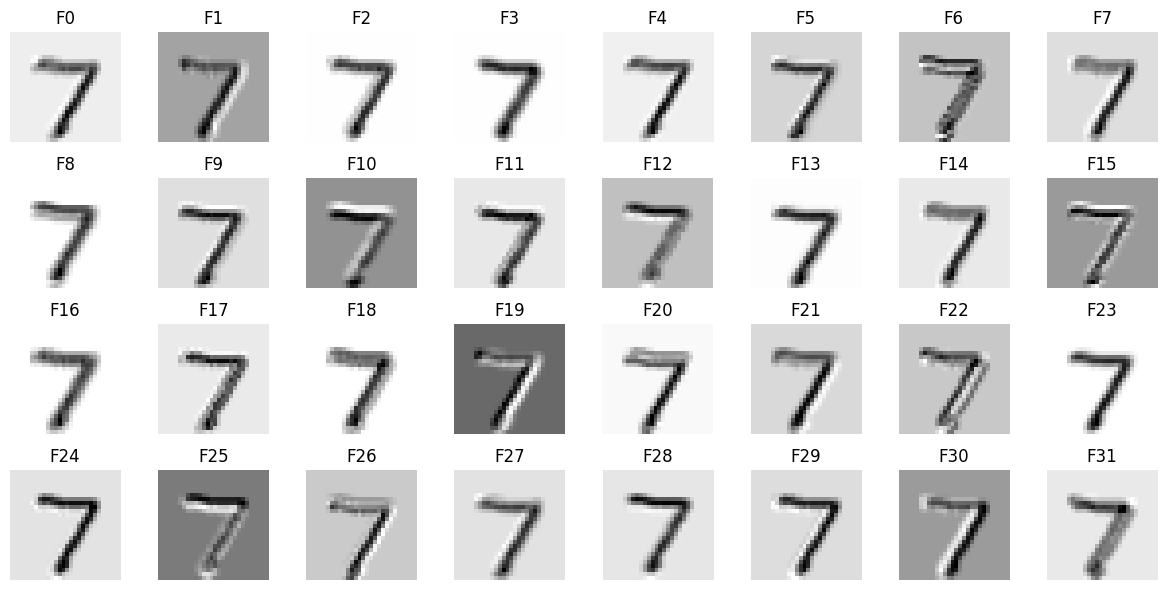

In [12]:
feature_maps = feature_maps.detach().cpu()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    ax.imshow(feature_maps[0, i], cmap='gray')

    ax.axis('off')

    ax.set_title(f"F{i}")

plt.tight_layout()

plt.show()